In [1]:
# !pip install missingno
# !pip uninstall pandas_profiling

In [29]:
# Do the necessary import
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

import warnings
warnings.filterwarnings('ignore')

import missingno as msno # missing data visualization module for Python
# import pandas_profiling

import gc
import datetime

pickle_file = "data_e_commerce_clean.pkl"

# %matplotlib inline

# sns.set_style('whitegrid')

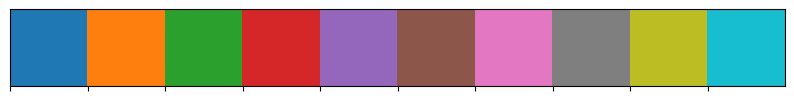

In [30]:
# Lets look at available colors
color = sns.color_palette()
# color available
sns.palplot(color)

In [31]:
df = pd.read_pickle(pickle_file)
print(df.head(10))

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   white hanging heart t-light holder         6   
1    536365     71053                  white metal lantern         6   
2    536365    84406B       cream cupid hearts coat hanger         8   
3    536365    84029G  knitted union flag hot water bottle         6   
4    536365    84029E       red woolly hottie white heart.         6   
5    536365     22752         set 7 babushka nesting boxes         2   
6    536365     21730    glass star frosted t-light holder         6   
7    536366     22633               hand warmer union jack         6   
8    536366     22632            hand warmer red polka dot         6   
9    536367     84879        assorted colour bird ornament        32   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26

In [32]:
# Lets verify that above works
print(df.info(memory_usage='deep'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392732 entries, 0 to 392731
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392732 non-null  category      
 1   StockCode    392732 non-null  category      
 2   Description  392732 non-null  category      
 3   Quantity     392732 non-null  int32         
 4   InvoiceDate  392732 non-null  datetime64[ns]
 5   UnitPrice    392732 non-null  float64       
 6   CustomerID   392732 non-null  float32       
 7   Country      392732 non-null  category      
dtypes: category(4), datetime64[ns](1), float32(1), float64(1), int32(1)
memory usage: 13.7 MB
None


In [33]:
# Calculate Total Amount for each row (Quantity × UnitPrice)
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [34]:
print(df.columns.to_list())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalAmount']


In [35]:
# rearrange all the columns for easy reference
df = df[['InvoiceNo','InvoiceDate','StockCode','Description',
                 'Quantity','UnitPrice','TotalAmount','CustomerID','Country']]

In [36]:
df.insert(loc=2, column='year_month', value=df['InvoiceDate'].map(lambda x: 100*x.year + x.month))
df.insert(loc=3, column='month', value=df.InvoiceDate.dt.month)
# +1 to make Monday=1.....until Sunday=7
df.insert(loc=4, column='day', value=(df.InvoiceDate.dt.dayofweek)+1)
df.insert(loc=5, column='hour', value=df.InvoiceDate.dt.hour)

In [37]:
print(df.head())

  InvoiceNo         InvoiceDate  year_month  month  day  hour StockCode  \
0    536365 2010-12-01 08:26:00      201012     12    3     8    85123A   
1    536365 2010-12-01 08:26:00      201012     12    3     8     71053   
2    536365 2010-12-01 08:26:00      201012     12    3     8    84406B   
3    536365 2010-12-01 08:26:00      201012     12    3     8    84029G   
4    536365 2010-12-01 08:26:00      201012     12    3     8    84029E   

                           Description  Quantity  UnitPrice  TotalAmount  \
0   white hanging heart t-light holder         6       2.55        15.30   
1                  white metal lantern         6       3.39        20.34   
2       cream cupid hearts coat hanger         8       2.75        22.00   
3  knitted union flag hot water bottle         6       3.39        20.34   
4       red woolly hottie white heart.         6       3.39        20.34   

   CustomerID         Country  
0     17850.0  United Kingdom  
1     17850.0  United Kingdo

In [38]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392732 entries, 0 to 392731
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392732 non-null  category      
 1   InvoiceDate  392732 non-null  datetime64[ns]
 2   year_month   392732 non-null  int64         
 3   month        392732 non-null  int32         
 4   day          392732 non-null  int32         
 5   hour         392732 non-null  int32         
 6   StockCode    392732 non-null  category      
 7   Description  392732 non-null  category      
 8   Quantity     392732 non-null  int32         
 9   UnitPrice    392732 non-null  float64       
 10  TotalAmount  392732 non-null  float64       
 11  CustomerID   392732 non-null  float32       
 12  Country      392732 non-null  category      
dtypes: category(4), datetime64[ns](1), float32(1), float64(2), int32(4), int64(1)
memory usage: 22.4 MB
None


# EDA

In [39]:
df['CustomerID'] = df['CustomerID'].astype('int64')

# Top 10 big spenders:

In [49]:
# Group by Customer & Calculate Spending
customer_spend = df.groupby('CustomerID')['TotalAmount'].sum().reset_index()

In [52]:
customer_spend.sort_values(by='TotalAmount', ascending=False).head(10)

,CustomerID,TotalAmount
1690,14646,280206.02
4202,18102,259657.30
3729,17450,194390.79
3009,16446,168472.50
1880,14911,143711.17
55,12415,124914.53
1334,14156,117210.08
3772,17511,91062.38
2703,16029,80850.84
0,12346,77183.60


# Top-Selling Products by Quantity

In [53]:
top_products = df.groupby('Description')['Quantity'].sum() \
                 .sort_values(ascending=False).head(10)

print(top_products)

Description
paper craft , little birdie           80995
medium ceramic top storage jar        77916
world war 2 gliders asstd designs     54319
jumbo bag red retrospot               46078
white hanging heart t-light holder    36706
assorted colour bird ornament         35263
pack of 72 retrospot cake cases       33670
popcorn holder                        30919
rabbit night light                    27153
mini paint set vintage                26076
Name: Quantity, dtype: int32


# How many different types of description values are there

In [56]:
print(df["Description"].value_counts())

Description
white hanging heart t-light holder    2016
regency cakestand 3 tier              1714
jumbo bag red retrospot               1615
assorted colour bird ornament         1395
party bunting                         1390
                                      ... 
jam jar with blue lid                    1
black drop earrings w long beads         1
jardin etched glass butter dish          1
jet black las vegas bracelet round       1
large black diamante hairslide           1
Name: count, Length: 3877, dtype: int64


# Monthly Revenue for year 2011

In [62]:
monthly_revenue = df[df["year_month"] > 201012].groupby('year_month')['TotalAmount'].sum().reset_index()
print(monthly_revenue)


    year_month  TotalAmount
0       201101   568101.310
1       201102   446084.920
2       201103   594081.760
3       201104   468374.331
4       201105   677355.150
5       201106   660046.050
6       201107   598962.901
7       201108   644051.040
8       201109   950690.202
9       201110  1035642.450
10      201111  1156205.610
11      201112   517190.440


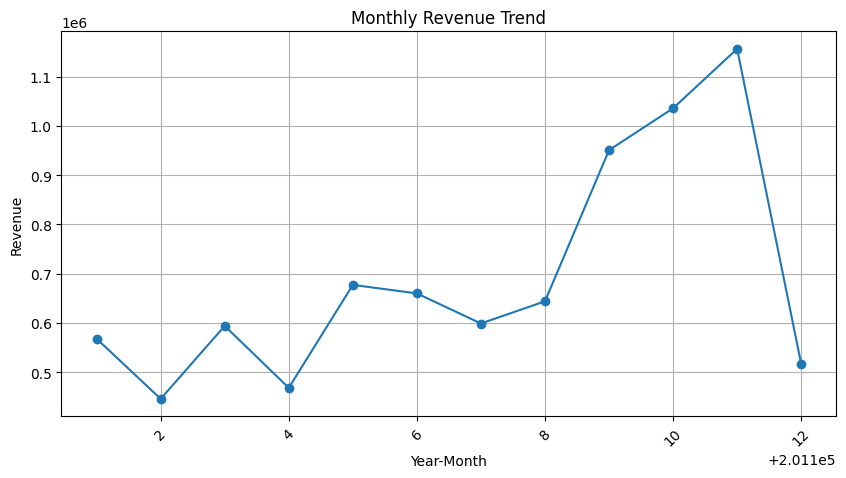

In [63]:
plt.figure(figsize=(10,5))
plt.plot(monthly_revenue['year_month'], monthly_revenue['TotalAmount'], marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


# Segmentation using total spending.
- Segment customers into groups: “High Value”, “Medium Value”, “Low Value”.

In [64]:
customer_value = df.groupby('CustomerID')['TotalAmount'].sum().reset_index()
customer_value.rename(columns={'TotalAmount':'TotalSpending'}, inplace=True)

In [65]:
customer_value['Segment'] = pd.qcut(
    customer_value['TotalSpending'],
    q=3,             # 3 segments
    labels=['Low Value','Medium Value','High Value']
)


In [69]:
print(len(customer_value))
print(customer_value.head())

4339
   CustomerID  TotalSpending     Segment
0       12346       77183.60  High Value
1       12347        4310.00  High Value
2       12348        1797.24  High Value
3       12349        1757.55  High Value
4       12350         334.40   Low Value


In [70]:
print(customer_value['Segment'].value_counts())

Segment
High Value      1447
Low Value       1446
Medium Value    1446
Name: count, dtype: int64
